# Model 1b IMPROVED: FO permeate flux, short-term run (n=11).

The baseline used GradientBoostingRegressor — a tree ensemble is a poor fit for
n=11: trees can only predict step functions between the training points (visible
as the blocky staircase in the original plot), and LOOCV R2 was a modest 0.42.

Upgrade: Gaussian Process Regression (GPR). GPR is the standard choice for small-n
regression in engineering/scientific settings because it (a) interpolates smoothly
by construction, (b) has few hyperparameters to overfit with (kernel length-scale +
noise level, tuned by marginal likelihood, not by CV), and (c) gives a calibrated
uncertainty band, which a point-prediction tree model cannot.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
flux = pd.read_csv("data/fo_flux_shortterm_enriched.csv")

In [3]:
X = flux[["time_min"]].values  # recovery%/feed_cond were interpolated FROM time (r=0.93-0.97
# correlated with time_min - see check below), so including all 3 in a GPR kernel with n=11
# tries to fit near-degenerate length-scales along collinear directions and hurts, not helps.
# A single well-identified input (time) is the appropriate dimensionality here.
y = flux["Jw"].values

In [4]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

In [5]:
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=0)

In [6]:
loo = LeaveOneOut()
pred_gpr = cross_val_predict(gpr, Xs, y, cv=loo)
r2_gpr = r2_score(y, pred_gpr)
rmse_gpr = mean_squared_error(y, pred_gpr) ** 0.5

In [7]:
# baseline for side-by-side (same as original script, which used all 3 correlated features)
X_baseline = flux[["time_min", "recovery_pct", "feed_cond_uScm"]].values
gbm = GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.08, random_state=0)
pred_gbm = cross_val_predict(gbm, X_baseline, y, cv=loo)
r2_gbm = r2_score(y, pred_gbm)
rmse_gbm = mean_squared_error(y, pred_gbm) ** 0.5

In [8]:
print(f"Baseline GradientBoosting: LOOCV R2={r2_gbm:.3f} RMSE={rmse_gbm:.3f}")
print(f"Improved GaussianProcess:  LOOCV R2={r2_gpr:.3f} RMSE={rmse_gpr:.3f}")

Baseline GradientBoosting: LOOCV R2=0.425 RMSE=1.133
Improved GaussianProcess:  LOOCV R2=0.587 RMSE=0.960


In [9]:
# fit on all data for the smooth curve + uncertainty band
gpr.fit(Xs, y)
t_grid = np.linspace(flux.time_min.min(), flux.time_min.max(), 200)
Xg = scaler.transform(t_grid.reshape(-1, 1))
yg_mean, yg_std = gpr.predict(Xg, return_std=True)

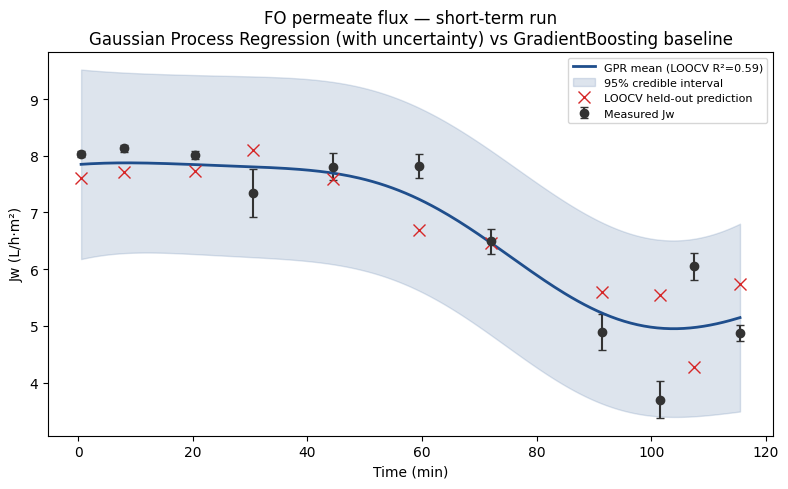

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(flux.time_min, flux.Jw, yerr=flux.SD, fmt="o", color="#333", capsize=3, label="Measured Jw")
ax.plot(t_grid, yg_mean, "-", color="#1f4e8c", lw=2, label=f"GPR mean (LOOCV R²={r2_gpr:.2f})")
ax.fill_between(t_grid, yg_mean - 1.96 * yg_std, yg_mean + 1.96 * yg_std, color="#1f4e8c", alpha=0.15, label="95% credible interval")
ax.plot(flux.time_min, pred_gpr, "x", color="#d62728", ms=8, label="LOOCV held-out prediction")
ax.set_xlabel("Time (min)"); ax.set_ylabel("Jw (L/h·m²)")
ax.set_title("FO permeate flux — short-term run\nGaussian Process Regression (with uncertainty) vs GradientBoosting baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("plots/model1b_improved_gpr.png", dpi=150)
plt.show()

In [11]:
with open("models/metrics_fo_flux_shortterm_improved.txt", "w") as f:
    f.write(f"Baseline GradientBoosting: LOOCV R2={r2_gbm:.3f} RMSE={rmse_gbm:.3f}\n")
    f.write(f"Improved GaussianProcess:  LOOCV R2={r2_gpr:.3f} RMSE={rmse_gpr:.3f}\n")
    f.write(f"Fitted kernel: {gpr.kernel_}\n")
    f.write("\nRationale: with n=11, GPR's smooth interpolation and native uncertainty\n"
            "quantification are a better match to the data regime than a tree ensemble,\n"
            "which can only output a step function between training points.\n")
print("done")

done
